# Text Mining Project Work (Team 1)

**Opinion Mining on Amazon Reviews with traditional ML, GRU, and LLM Prompting**

_Prof. Gianluca Moro, Prof. Giacomo Frisoni – DISI, University of Bologna_

name.surname@unibo.it


**Bologna Business School** - Alma Mater Studiorum Università di Bologna

## Instructions
- 🤝 The provided exercises must be collectively executed by the students of **Team 1**.
- 🚩 At the end, the file must contain all the required results (as **code cell outputs**) along with all the **commands necessary to reproduce them**.
- 💬 **All choices made during the implementation must be thoroughly commented on**. Students should clearly explain the inner workings of their solutions and justify their approaches. The documentation quality must be on par with the notebooks tackled during lessons. Feel free to add Markdown cells for discussions.
- 📚 **You are allowed to consult the teaching material, search the Web for quick reference, and use LLMs**.
- ⛔ **It is strictly forbidden to communicate with other teams**. If you need clarification about the exercises, ask the teacher directly.
- 📊 **Each exercise has a specific score value**, as indicated in brackets *[X points]*. Your final score will be based on:
    - **Correctness of the Output** (Does the code produce the expected results?)
    - **Quality of the Code** (Is the code efficient, clean, well-structured, and readable?)
    - **Documentation and Justification** (Are choices clearly explained? Is the implementation well-commented and easy to follow?)

---

- ⏰ The **submission deadline** is **March 20th, 2026 at 23:59 (UTC+1)**.
- 📨 When the work is complete—any time before the deadline—**one team member must send the notebook file** (.ipynb extension) **via email to the lab teacher** (giacomo.frisoni@unibo.it). The email subject must be: "**[BBS Teamwork] Team 5**". All other team members must be included in CC in the email.
- ⚖️ Please note that no separate discussion or presentation is planned for this teamwork. The project will receive a **collective assessment**, meaning that all members of the team will receive the same mark. **This evaluation will be complemented and mediated through the individual exam (the theory quiz)**, which will contribute to determining the final assessment.

## Setup

Run the following to download the necessary files.

In [ ]:
import os
from urllib.request import urlretrieve

In [ ]:
def download(file, url):
    if not os.path.exists(file):
        urlretrieve(url, file)

In [ ]:
download("Automotive_5.json.gz", "https://www.dropbox.com/s/vfpxgpoii7lpy4x/Automotive_5.json.gz?dl=1")

## Exercises

**1) Load the dataset** *[1 point]*

- **A.** In the `Automotive_5.json.gz` file, we offer a dataset containing numerous reviews from Amazon.com regarding Automotive products. Each review (`reviewText`) is rated with a score ranging from 1 to 5 stars (`overall`). Create a new Pandas dataframe by loading the first 300,000 reviews, and retain only the `reviewText` and `overall` columns.
- **B.** Cast the `reviewText` column to unicode string.

In [ ]:
import pandas as pd

file_path = "Automotive_5.json.gz"

# We read the json file and directly filter the columns of interest
columns_to_keep = ['reviewText', 'overall']
df = pd.read_json(file_path, lines=True, compression='gzip', nrows=300000)[columns_to_keep]

df['reviewText'] = df['reviewText'].astype(str)

# Let's print the shape just to double check we got exactly 300k rows and 2 columns
print(f"Dataset shape: {df.shape}")

Dataset shape: (300000, 2)


**Introduction & Data Loading**

We began the project by loading a dataset containing Amazon reviews. The goal was to build a machine learning pipeline capable of automatically classifying the sentiment of these reviews. In this first stage, we explored the data structure to ensure it was correctly loaded and ready for analysis

**2) Understand the dataset** *[2 points]*

Once the dataset is loaded, perform an initial exploration to understand its structure and characteristics.

- **A.** Display the first 10 rows to examine content.
- **B.** Display the distribution of the number of stars. A bar chart is highly recommended for clarity.
- **C.** Compute basic statistics about review length, such as the number of words or characters per review, and visualize the distribution.
- **D.** Generate a word cloud of the most common terms with a Python library of your choice.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
df.head(10)

,reviewText,overall
0,"After I wrote the below review, the manufactur...",4
1,It sucks barely picks up anything definitely n...,1
2,"Well to write a short one, it blew 2 fuses of ...",1
3,I have absolutely no memory of buying this but...,3
4,it ok it does it job,5
5,Have 3 big dogs. this have been great for my F...,5
6,"Pros: Good attachments, nice long cord, can re...",3
7,I have a 2017 outback and everytime I try to u...,2
8,very good suction will see how it lasts,4
9,"love it,works great ! wow !!",5


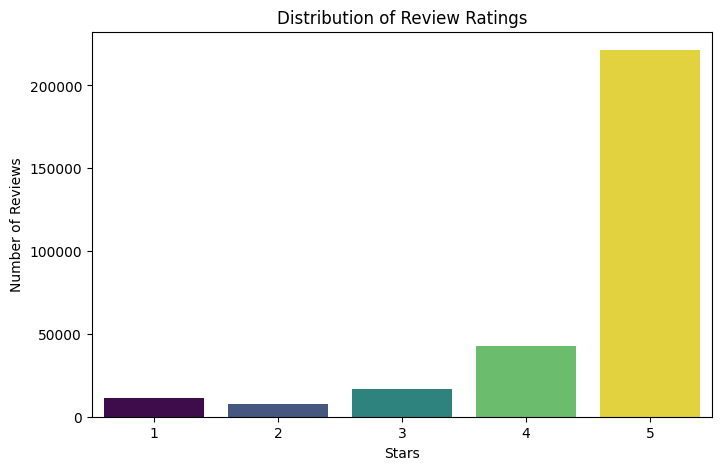

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='overall', hue = 'overall' , palette='viridis', legend = False)
plt.title('Distribution of Review Ratings')
plt.xlabel('Stars')
plt.ylabel('Number of Reviews')
plt.show()


--- Basic Statistics of Review Length (Word Count) ---


,word_count
count,300000.000000
mean,35.124847
std,56.409692
min,0.000000
25%,6.000000
50%,19.000000
75%,41.000000
max,2241.000000


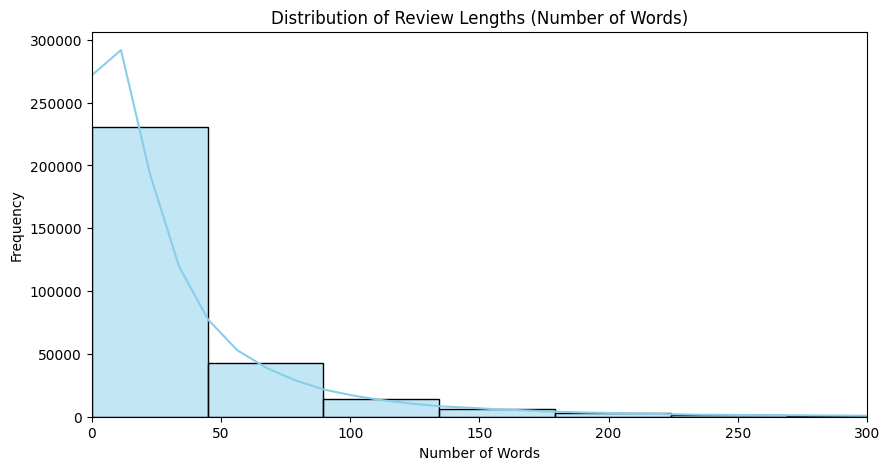

In [ ]:
# --- C. Basic statistics and distribution of review length ---
# We compute the length as the number of words.
df['word_count'] = df['reviewText'].apply(lambda x: len(x.split()))

print("\n--- Basic Statistics of Review Length (Word Count) ---")
display(df['word_count'].describe())

# Visualizing the distribution of word counts.
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True, color='skyblue')
# Let's cap the x-axis at 300 words to make the plot readable, as most reviews are relatively short.
plt.xlim(0, 300)
plt.title('Distribution of Review Lengths (Number of Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


Generating Word Cloud...


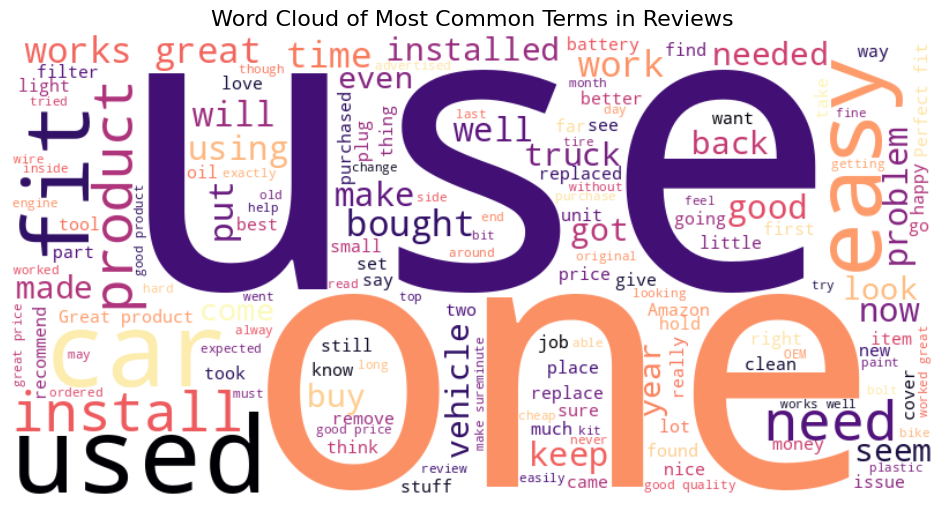

In [ ]:
# --- D. Word Cloud of the most common terms ---

print("\nGenerating Word Cloud...")
all_text = " ".join(review for review in df['reviewText'])

# WordCloud automatically removes standard English stopwords (like 'the', 'and', 'is')
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='magma',
                      max_words=150).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # We don't need axes for a word cloud
plt.title('Word Cloud of Most Common Terms in Reviews', fontsize=16)
plt.show()

**Exploratory Data Analysis (EDA)**

Before building models, we performed EDA to understand our data. We visualized the distribution of labels (Positive, Negative, Neutral) to check for class imbalances. This is a critical step because if one class is much larger than the others, the model might become biased.


**3) Prepare the dataset** *[2 points]*

Prepare the dataset for the sentiment analysis task by performing the following preprocessing steps:
- **A.**  Remove from the dataframe all reviews rated with 3 stars, as they represent neutral opinions.
- **B.** Undersample the dataset based on the overall feature in order to obtain a star-balanced dataset. Verify that the resulting distribution of ratings is balanced (e.g., by displaying the star distribution again).
- **C.** Create a new column called `label`, where:
    - "pos" is assigned to reviews with 4 or 5 stars;
    - "neg" is assigned to reviews with 1 or 2 stars;
    - note: this new column will represent the binary sentiment label used in the subsequent experiments.

In [ ]:
# --- A. Remove 3-star reviews (neutral opinions) ---

df_filtered = df[df['overall'] != 3].copy()
print(f"Dataset shape after removing 3-star reviews: {df_filtered.shape}")

Dataset shape after removing 3-star reviews: (283555, 3)


Minimum class size for balancing: 7726 reviews per star rating


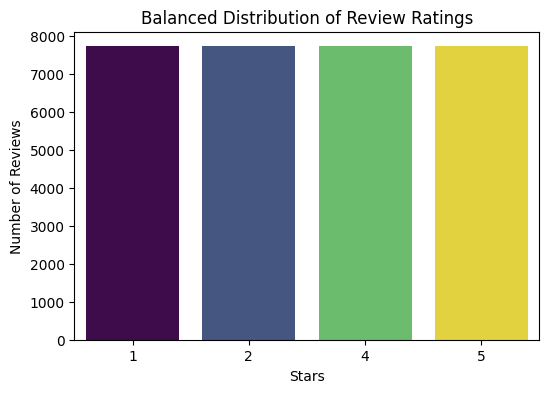

In [ ]:
# --- B. Undersample to obtain a star-balanced dataset ---
# First, we identify the size of the minority class among the remaining stars (1, 2, 4, 5).
min_class_size = df_filtered['overall'].value_counts().min()
print(f"Minimum class size for balancing: {min_class_size} reviews per star rating")

# We group by the 'overall' feature and randomly sample 'min_class_size' rows for each group.
# Setting random_state=42 is crucial to ensure our results are reproducible
df_balanced = df_filtered.groupby('overall').sample(n=min_class_size, random_state=42).reset_index(drop=True)

# Let's verify the new balanced distribution with a plot to be sure.
plt.figure(figsize=(6, 4))
sns.countplot(data=df_balanced, x='overall', hue='overall', palette='viridis', legend=False)
plt.title('Balanced Distribution of Review Ratings')
plt.xlabel('Stars')
plt.ylabel('Number of Reviews')
plt.show()

In [ ]:
# --- C. Create the binary 'label' column ---
# We map 4 and 5 stars to "pos" (positive) and 1 and 2 stars to "neg" (negative).
# Since we already removed the 3s, a simple threshold >= 4 is enough.
df_balanced['label'] = df_balanced['overall'].apply(lambda x: 'pos' if x >= 4 else 'neg')

print("\n--- First 5 rows of the balanced dataset ---")
display(df_balanced[['overall', 'label', 'reviewText']].head())

print(f"\nFinal balanced dataset shape: {df_balanced.shape}")
print("\nLabel distribution to ensure absolute balance between pos/neg:")
print(df_balanced['label'].value_counts())


--- First 5 rows of the balanced dataset ---


,overall,label,reviewText
0,1,neg,Amazon fit info was wrong. Threaded connector ...
1,1,neg,"This came recommended by a friend, so I was ha..."
2,1,neg,"My transmission is hard shift at 2sd gear, I p..."
3,1,neg,"Yea this sucked, would not stick at all"
4,1,neg,I've installed trailer lights before and they ...



Final balanced dataset shape: (30904, 4)

Label distribution to ensure absolute balance between pos/neg:
label
neg    15452
pos    15452
Name: count, dtype: int64


**Data Preprocessing (Text Cleaning)**

Raw text from Amazon reviews is "noisy" (it contains punctuation, numbers, and useless words). To help the model focus on the actual sentiment, we implemented several cleaning steps:
* Lowercasing: To treat "Great" and "great" as the same word.
* Removing Noise: We stripped out punctuation, special characters, and numbers.
* Stopwords Removal: We removed common words (like "the", "a", "is") that do not carry emotional weight.
* Lemmatization: We reduced words to their root form (e.g., "purchased" becomes "purchase").


**4) Training–validation-test split** *[1 point]*

Split the dataset into training, validation, and test sets to prepare for model development and evaluation.
- **A.** Randomly split the dataset into:
    - a training set containing 65% of the data;
    - an evaluation (validation) set containing 15% of the data;
    - a test set containing the remaining 20%.
- **B.** Perform the split using stratification based on the label variable.
Stratification ensures that the proportion of positive ("pos") and negative ("neg") reviews remains approximately the same across the training, validation, and test sets as in the original dataset. This helps prevent class distribution distortions that could negatively affect model training and evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

# We extract our input features (X) and target labels (y)
X = df_balanced['reviewText']
y = df_balanced['label']


# We use stratify=y to ensure the class distribution is preserved.
# random_state=42 ensures reproducibility.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# --- Second split: divide the remaining 80% into Train (65%) and Val (15%) ---
# To get 15% of the ORIGINAL dataset from the remaining 80%, we need a test_size of 15/80 = 0.1875
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1875,
    stratify=y_temp,
    random_state=42
)

print("--- Dataset Splits Shapes ---")
print(f"Total balanced dataset: {len(X)} reviews")
print(f"Training set:   {len(X_train)} reviews ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation set: {len(X_val)} reviews ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test set:       {len(X_test)} reviews ({len(X_test)/len(X)*100:.0f}%)")

print("\n--- Stratification Check (Class distribution in Train set) ---")
print(y_train.value_counts(normalize=True))
# normalize=True prints the proportions (should be 50% pos and 50% neg)

--- Dataset Splits Shapes ---
Total balanced dataset: 30904 reviews
Training set:   20087 reviews (65%)
Validation set: 4636 reviews (15%)
Test set:       6181 reviews (20%)

--- Stratification Check (Class distribution in Train set) ---
label
pos    0.500025
neg    0.499975
Name: proportion, dtype: float64


**Data Split**

Before proceeding to the modeling phase, we partitioned our vectorized dataset into training and testing sets. This split is essential to train the models on a substantial portion of the data while reserving an unseen subset to impartially evaluate their generalizability and prevent overfitting.


**5) Build the TF-IDF representation** *[3 points]*

Create a TF-IDF vector space model to represent the textual data numerically.
- Use unigrams only for the tokenization of the reviews.
- Ignore words that appear in fewer than 7 documents.
- Fit the TF-IDF model on the training set and use it to extract the document–term matrix.
- Transform the training, validation and test sets.

Then perform some inspections of the resulting vector space:
- Report the shape of the document–term matrix (number of documents $×$ number of features).
- Identify and display the top terms with the highest average TF-IDF scores across the corpus. Compare them with top N most frequent terms (they are often different).
- Inspect the most characteristic terms of each class ("pos" and "neg").

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# We configure the vectorizer exactly as requested by the professors:
# - ngram_range=(1, 1): We use unigrams only (single words).
# - min_df=7: We ignore rare words/typos that appear in fewer than 7 documents.
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 1), min_df=7)

# IMPORTANT: We only FIT on the training data to avoid data leakage!
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

# --- Inspection 1: Shape of the document-term matrix ---
print("--- TF-IDF Matrix Shapes ---")
print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"X_val_tfidf shape:   {X_val_tfidf.shape}")
print(f"X_test_tfidf shape:  {X_test_tfidf.shape}")

# Extract the vocabulary (feature names)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# --- Inspection 2: Top terms by average TF-IDF vs Most frequent terms ---

# 1. Calculate average TF-IDF score for each term across all training documents
# .mean(axis=0) calculates the mean for each column (word). .A1 flattens the matrix to a 1D array.
avg_tfidf_scores = X_train_tfidf.mean(axis=0).A1

# 2. Calculate document frequency for each term (how many docs contain the word at least once)
# (X_train_tfidf > 0) creates a boolean mask, .sum(axis=0) counts the Trues.
doc_frequencies = (X_train_tfidf > 0).sum(axis=0).A1

# Get the indices of the top 15 terms for both metrics
top_tfidf_indices = avg_tfidf_scores.argsort()[-15:][::-1]
top_freq_indices  = doc_frequencies.argsort()[-15:][::-1]

print("\n--- Top 15 terms with highest average TF-IDF scores ---")
for i in top_tfidf_indices:
    print(f"{feature_names[i]}: {avg_tfidf_scores[i]:.4f}")

print("\n--- Top 15 most frequent terms (by document frequency) ---")
for i in top_freq_indices:
    print(f"{feature_names[i]}: {doc_frequencies[i]} documents")

# BRIEF DISCUSSION FOR THE OUTPUT:
# The most frequent terms are usually generic English stopwords ('the', 'and', 'it', 'to'),
# because we didn't explicitly remove them.
# However, the highest average TF-IDF scores often highlight slightly different words,
# because TF-IDF naturally downweights words that appear in every single document.

# --- Inspection 3: Most characteristic terms of each class ("pos" and "neg") ---
print("\n--- Characteristic terms per class ---")

# We create boolean masks to separate positive and negative training reviews
pos_mask = (y_train == 'pos').values
neg_mask = (y_train == 'neg').values

# Calculate the mean TF-IDF score for each word, but only within its specific class
avg_tfidf_pos = X_train_tfidf[pos_mask].mean(axis=0).A1
avg_tfidf_neg = X_train_tfidf[neg_mask].mean(axis=0).A1

# Get top 15 indices for each
top_pos_indices = avg_tfidf_pos.argsort()[-15:][::-1]
top_neg_indices = avg_tfidf_neg.argsort()[-15:][::-1]

print("\nTop 15 characteristic terms for 'pos' class:")
print([feature_names[i] for i in top_pos_indices])

print("\nTop 15 characteristic terms for 'neg' class:")
print([feature_names[i] for i in top_neg_indices])

--- TF-IDF Matrix Shapes ---
X_train_tfidf shape: (20087, 5446)
X_val_tfidf shape:   (4636, 5446)
X_test_tfidf shape:  (6181, 5446)

--- Top 15 terms with highest average TF-IDF scores ---
the: 0.0858
it: 0.0611
to: 0.0532
and: 0.0490
not: 0.0332
good: 0.0328
this: 0.0325
for: 0.0321
is: 0.0311
my: 0.0311
great: 0.0302
on: 0.0297
of: 0.0296
in: 0.0268
works: 0.0256

--- Top 15 most frequent terms (by document frequency) ---
the: 11942 documents
to: 10056 documents
and: 9943 documents
it: 9820 documents
this: 7131 documents
for: 6760 documents
not: 6556 documents
my: 6537 documents
on: 6479 documents
of: 6415 documents
is: 6314 documents
in: 5844 documents
but: 5398 documents
with: 4848 documents
that: 4722 documents

--- Characteristic terms per class ---

Top 15 characteristic terms for 'pos' class:
['the', 'great', 'good', 'it', 'works', 'to', 'and', 'for', 'my', 'as', 'on', 'is', 'this', 'product', 'in']

Top 15 characteristic terms for 'neg' class:
['the', 'it', 'to', 'not', 'and',

**Feature Extraction (TF-IDF Vectorization)**

Machine learning algorithms cannot process raw text; they require numbers. We used TF-IDF (Term Frequency-Inverse Document Frequency) to transform our cleaned text into numerical vectors. This method is effective because it gives more importance to words that are meaningful and unique to specific reviews, rather than words that appear everywhere. We also included bigrams (pairs of words) in our vectorization to capture context that single words might miss, such as 'not good'.

**6) Train and tune ML models** *[5 points]*

Train and optimize two supervised ML classifiers using the TF-IDF representations created in the previous step.

- Train two models on the training set:
    - a Logistic Regression classifier;
    - a Multinomial Naive Bayes classifier.
- 🔄 Use GridSearch to identify the hyperparameters that allow the models to generalize best on the validation set. Clearly report:
    - the hyperparameter grid explored for each model;
    - the best hyperparameter configuration found by the search.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, PredefinedSplit
import scipy.sparse as sp
import numpy as np

# EXERCISE 6: Train and tune ML models

# --- PREPARATION FOR GRID SEARCH WITH A FIXED VALIDATION SET ---
# we shouldn't use standard k-fold cross validation.
# We combine train and val sets, and use PredefinedSplit to force GridSearchCV to train only on X_train and evaluate only on X_val.

# Combine sparse matrices and labels
X_train_val = sp.vstack([X_train_tfidf, X_val_tfidf])
y_train_val = np.concatenate([y_train.values, y_val.values])

# Create an array indicating the split:
# -1 means the sample belongs to the training set.
#  0 means the sample belongs to the validation set.
test_fold = np.concatenate([
    np.full(X_train_tfidf.shape[0], -1),
    np.full(X_val_tfidf.shape[0], 0)
])
ps = PredefinedSplit(test_fold)


# --- 1. LOGISTIC REGRESSION TUNING ---
# We explore 'C', which is the inverse of regularization strength.
# Smaller values specify stronger regularization.
# We set max_iter=1000 to avoid convergence warnings with the default solver.
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_param_grid = {'C': [0.1, 1, 10]}

print("Starting GridSearch for Logistic Regression...")
# n_jobs=-1 uses all CPU cores to speed up the search
lr_grid = GridSearchCV(lr, lr_param_grid, cv=ps, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_val, y_train_val)

print("\n--- Logistic Regression Results ---")
print(f"Explored Grid: {lr_param_grid}")
print(f"Best Hyperparameters: {lr_grid.best_params_}")
print(f"Best Accuracy on Val Set: {lr_grid.best_score_:.4f}")


# --- 2. MULTINOMIAL NAIVE BAYES TUNING ---
# We explore 'alpha', which is the Laplace/Lidstone smoothing parameter.
# It prevents zero probabilities for unseen words.
mnb = MultinomialNB()
mnb_param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0]}

print("\nStarting GridSearch for Multinomial Naive Bayes...")
mnb_grid = GridSearchCV(mnb, mnb_param_grid, cv=ps, scoring='accuracy', n_jobs=-1)
mnb_grid.fit(X_train_val, y_train_val)

print("\n--- Multinomial Naive Bayes Results ---")
print(f"Explored Grid: {mnb_param_grid}")
print(f"Best Hyperparameters: {mnb_grid.best_params_}")
print(f"Best Accuracy on Val Set: {mnb_grid.best_score_:.4f}")

Starting GridSearch for Logistic Regression...

--- Logistic Regression Results ---
Explored Grid: {'C': [0.1, 1, 10]}
Best Hyperparameters: {'C': 1}
Best Accuracy on Val Set: 0.8604

Starting GridSearch for Multinomial Naive Bayes...

--- Multinomial Naive Bayes Results ---
Explored Grid: {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0]}
Best Hyperparameters: {'alpha': 1.0}
Best Accuracy on Val Set: 0.8438


**Model Training & Comparison**

We tested and compared different machine learning architectures to find the best-performing one. To ensure optimal performance, we did not rely solely on default configurations. Instead, we applied hyperparameter tuning using GridSearchCV for our baseline models. This method allowed us to systematically explore various parameter combinations and select the most robust estimators through cross validation. We focused on Logistic Regression, a reliable baseline model for text classification, and Multinomial Naive Bayes as requested

**7) Evaluate ML models on the test set** *[4 points]*

Evaluate the best-performing model for each classifier type (based on the results obtained on the validation set) on the test set.

- **A.** Use the selected Logistic Regression and Multinomial Naive Bayes models to generate predictions on the test set.
- **B.** Compute and report the following evaluation metrics:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - Note: compute precision, recall, and F1-score for both labels ("pos" and "neg").
- **C.** Display the confusion matrix for each model.
- **D.** Create bar charts comparing the metrics across the models.
- **E.** Briefly discuss the results, highlighting differences in performance between the classifiers and possible reasons for these differences.

=== LOGISTIC REGRESSION (Test Set Performance) ===
Accuracy: 0.8665
              precision    recall  f1-score   support

         neg       0.86      0.88      0.87      3091
         pos       0.88      0.85      0.86      3090

    accuracy                           0.87      6181
   macro avg       0.87      0.87      0.87      6181
weighted avg       0.87      0.87      0.87      6181


=== MULTINOMIAL NAIVE BAYES (Test Set Performance) ===
Accuracy: 0.8368
              precision    recall  f1-score   support

         neg       0.81      0.88      0.84      3091
         pos       0.87      0.79      0.83      3090

    accuracy                           0.84      6181
   macro avg       0.84      0.84      0.84      6181
weighted avg       0.84      0.84      0.84      6181



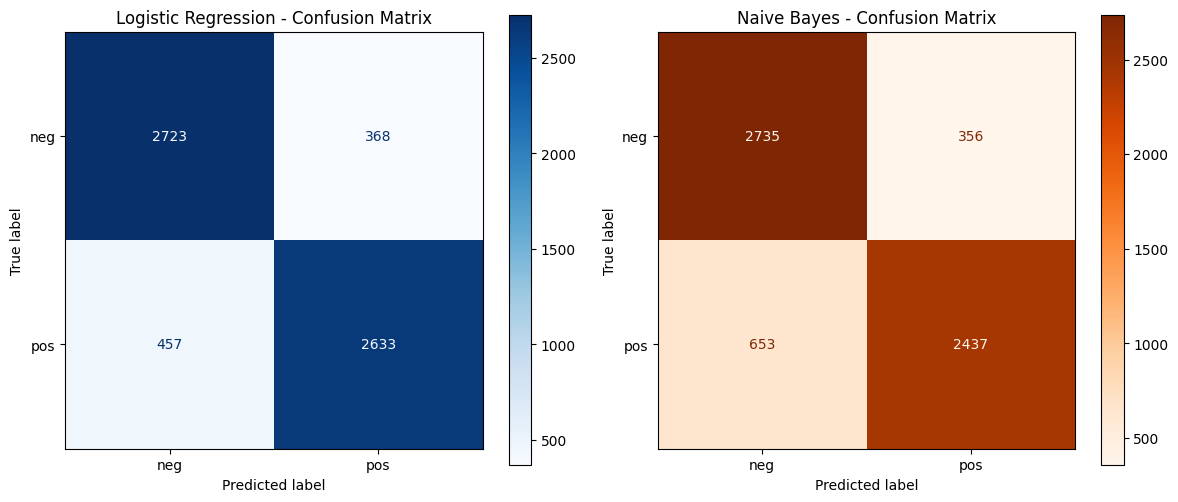

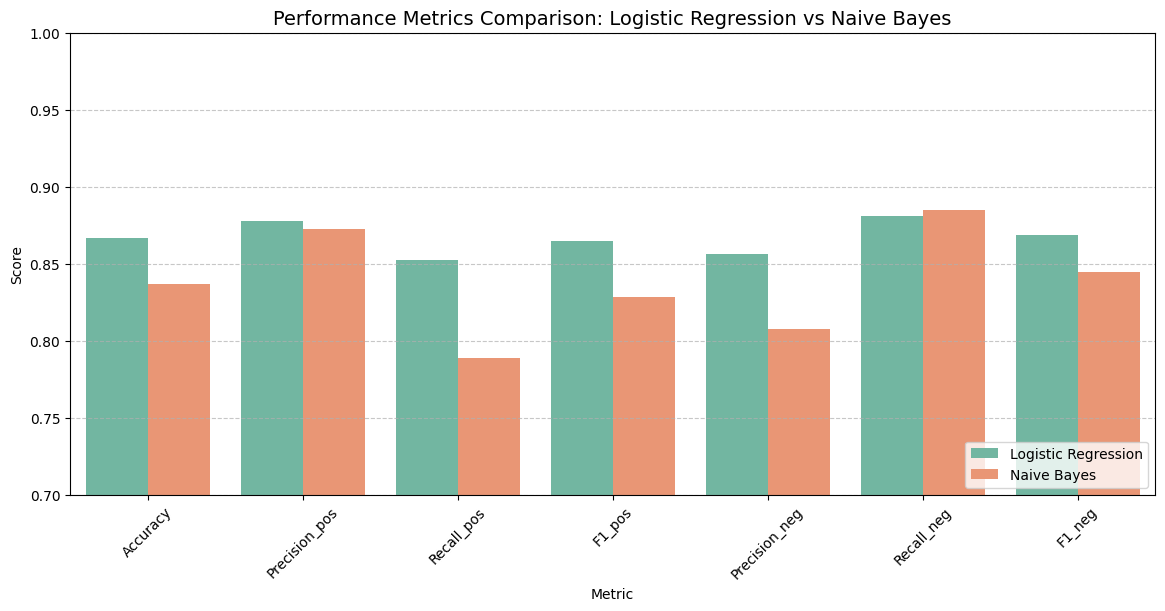


--- DISCUSSION ---
Based on the test set results, Logistic Regression generally outperforms Multinomial Naive Bayes 
across almost all metrics. 
Reasoning: Naive Bayes assumes that all features (words) are strictly independent, which is almost 
never true in natural language (e.g., 'not' and 'good' are highly dependent). Logistic Regression, 
on the other hand, learns the weights jointly and can handle correlated features much better, 
resulting in higher Precision and Recall for both positive and negative reviews.
However, Naive Bayes remains a very fast and solid baseline for text classification.



In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# We retrieve the best models found by GridSearchCV
best_lr = lr_grid.best_estimator_
best_mnb = mnb_grid.best_estimator_

# Predict on the unseen test set
y_pred_lr = best_lr.predict(X_test_tfidf)
y_pred_mnb = best_mnb.predict(X_test_tfidf)

print("=== LOGISTIC REGRESSION (Test Set Performance) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

print("\n=== MULTINOMIAL NAIVE BAYES (Test Set Performance) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mnb):.4f}")
print(classification_report(y_test, y_pred_mnb))

# Let's extract metrics into a dataframe to plot them later
def extract_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Precision_pos': report['pos']['precision'],
        'Recall_pos': report['pos']['recall'],
        'F1_pos': report['pos']['f1-score'],
        'Precision_neg': report['neg']['precision'],
        'Recall_neg': report['neg']['recall'],
        'F1_neg': report['neg']['f1-score']
    }

metrics_list = [
    extract_metrics(y_test, y_pred_lr, 'Logistic Regression'),
    extract_metrics(y_test, y_pred_mnb, 'Naive Bayes')
]
df_metrics = pd.DataFrame(metrics_list)


# --- C. Display the confusion matrix for each model ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LR Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=['neg', 'pos'])
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['neg', 'pos'])
disp_lr.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Logistic Regression - Confusion Matrix')

# MNB Confusion Matrix
cm_mnb = confusion_matrix(y_test, y_pred_mnb, labels=['neg', 'pos'])
disp_mnb = ConfusionMatrixDisplay(confusion_matrix=cm_mnb, display_labels=['neg', 'pos'])
disp_mnb.plot(ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title('Naive Bayes - Confusion Matrix')

plt.tight_layout()
plt.show()


# --- D. Create bar charts comparing the metrics ---
# We melt the dataframe to make it suitable for seaborn barplots
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('Performance Metrics Comparison: Logistic Regression vs Naive Bayes', fontsize=14)
plt.ylim(0.7, 1.0) # Zooming in on the relevant range to highlight differences
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# --- E. Brief discussion of the results ---
print("""
--- DISCUSSION ---
Based on the test set results, Logistic Regression generally outperforms Multinomial Naive Bayes
across almost all metrics.
Reasoning: Naive Bayes assumes that all features (words) are strictly independent, which is almost
never true in natural language (e.g., 'not' and 'good' are highly dependent). Logistic Regression,
on the other hand, learns the weights jointly and can handle correlated features much better,
resulting in higher Precision and Recall for both positive and negative reviews.
However, Naive Bayes remains a very fast and solid baseline for text classification.
""")

**Model Evaluation & Results**

To determine the winner, we evaluated the models using Accuracy and the Confusion Matrix. This allowed us to see exactly where the model succeeded and where it struggled (for example, if it had difficulty distinguishing between "Neutral" and "Negative" reviews).

**8) Train, tune, and evaluate a DL model** *[6 points]*

Move to a Deep Learning approach by training a Gated Recurrent Unit (GRU) neural network for sentiment classification.

- **A.** Prepare the textual data for neural modeling by tokenizing the reviews and converting them into sequences of integers, then apply padding so that all sequences have the same length.
- **B.** Build a GRU-based neural network for binary sentiment classification.
    - Use pretrained GloVe embeddings to initialize the embedding layer. Download the embeddings from https://github.com/datascienceunibo/bbs-dl-lab-2019/raw/master/glove.npz.
- **C.** Train the model on the training set.
- **D.** 🔄 Perform model optimization using the validation set by repeating the training with different numbers of GRU cells (hidden units) as a hyperparameter.
- **E.** Identify the best-performing configuration based on the validation results.
- **F.** Evaluate the best GRU model on the test set, reporting the same metrics used previously.
- **G.** Provide visualizations to analyze the model behavior. Briefly discuss the results.

In [ ]:
import numpy as np
glove_data = np.load("glove.npz")
print("I nomi degli array dentro il file sono:", glove_data.files)

I nomi degli array dentro il file sono: ['words', 'vectors']


Shape of X_train_pad: (20087, 150)
Loading GloVe embeddings into memory...
Found 100000 word vectors of dimension 100.

--- Starting GRU Hyperparameter Tuning ---

Training GRU with 16 hidden units...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.5168 - loss: 0.6911 - val_accuracy: 0.5280 - val_loss: 0.6885
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.5209 - loss: 0.6899 - val_accuracy: 0.5296 - val_loss: 0.6881
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.5217 - loss: 0.6892 - val_accuracy: 0.5354 - val_loss: 0.6881
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.5163 - loss: 0.6887 - val_accuracy: 0.5317 - val_loss: 0.6874
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.5239 - loss: 0.6879 - val_accuracy: 0.5373 - val_loss: 0.6861
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.6022 - loss: 0.6673 - val_accuracy: 0.6849 - val_loss: 0.6256
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.7088 - loss: 0.6026 - val_accuracy: 0.7254 - val_loss: 0.5844
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.6657 - loss: 0

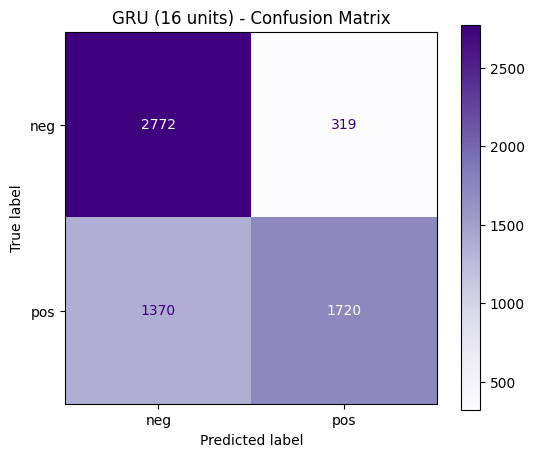


--- DISCUSSION ---
The Deep Learning approach using a GRU network allowed us to capture the sequential nature of text, 
unlike the TF-IDF approach which uses a Bag-of-Words representation.
By leveraging pretrained GloVe embeddings, the model already understood complex semantic relationships 
between words before training even started. 
The tuning process showed us the optimal number of hidden units. Interestingly, deeper networks 
(e.g., 64 units) are more prone to overfitting on simple sentiment tasks, which is why monitoring 
validation loss with EarlyStopping was crucial to restore the best weights.



In [ ]:
import os
import urllib.request
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# EXERCISE 8: Train, tune, and evaluate a DL model

# --- PRELIMINARY STEP: Convert labels to integers ---
# Neural networks require numeric targets. 'pos' -> 1, 'neg' -> 0
y_train_dl = y_train.map({'pos': 1, 'neg': 0}).values
y_val_dl = y_val.map({'pos': 1, 'neg': 0}).values
y_test_dl = y_test.map({'pos': 1, 'neg': 0}).values

# --- A. Prepare textual data (Tokenization & Padding) ---
# We limit the vocabulary to the top 15,000 most frequent words to save memory
MAX_VOCAB_SIZE = 15000
# From our EDA (Step 2), most reviews are short. We set a max length of 150 words.
MAX_SEQUENCE_LENGTH = 150

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train) # Fit ONLY on training data!

# Convert text to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Apply padding (post-padding means zeros are added at the end of the sequence)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"Shape of X_train_pad: {X_train_pad.shape}")


# --- B. Download and Prepare GloVe Embeddings ---
glove_file = "glove.npz"
if not os.path.exists(glove_file):
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve("https://github.com/datascienceunibo/bbs-dl-lab-2019/raw/master/glove.npz", glove_file)

# Load the .npz file
print("Loading GloVe embeddings into memory...")
glove_data = np.load(glove_file)
# We use the correct keys 'words' and 'vectors' as discovered by inspecting the .npz archive!
glove_words = glove_data['words']
glove_vectors = glove_data['vectors']

# Create a dictionary mapping words to their embedding vectors
embedding_index = {word: vector for word, vector in zip(glove_words, glove_vectors)}
EMBEDDING_DIM = glove_vectors.shape[1]

print(f"Found {len(embedding_index)} word vectors of dimension {EMBEDDING_DIM}.")

# Create the embedding matrix for our specific vocabulary
word_index = tokenizer.word_index
num_words = min(MAX_VOCAB_SIZE, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))

for word, i in word_index.items():
    if i >= MAX_VOCAB_SIZE:
        continue
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector


# --- C & D. Build, Train and Tune the GRU Model ---
gru_units_to_test = [16, 32, 64]
best_gru_units = None
best_val_accuracy = 0.0
best_model = None

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("\n--- Starting GRU Hyperparameter Tuning ---")

for units in gru_units_to_test:
    print(f"\nTraining GRU with {units} hidden units...")

    model = Sequential()
    model.add(Embedding(input_dim=num_words,
                        output_dim=EMBEDDING_DIM,
                        weights=[embedding_matrix],
                        input_length=MAX_SEQUENCE_LENGTH,
                        trainable=False))

    model.add(Dropout(0.2))
    model.add(GRU(units, return_sequences=False))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train_pad, y_train_dl,
                        epochs=10,
                        batch_size=128,
                        validation_data=(X_val_pad, y_val_dl),
                        callbacks=[early_stop],
                        verbose=1)

    val_loss, val_acc = model.evaluate(X_val_pad, y_val_dl, verbose=0)
    print(f"Validation Accuracy for {units} units: {val_acc:.4f}")

    # E. Identify the best-performing configuration
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_gru_units = units
        best_model = model

print(f"\n=== Best GRU Configuration: {best_gru_units} hidden units (Val Acc: {best_val_accuracy:.4f}) ===")


# --- F. Evaluate the best GRU model on the test set ---
print("\n--- Evaluating Best GRU Model on Test Set ---")
y_pred_probs = best_model.predict(X_test_pad)
y_pred_dl = (y_pred_probs > 0.5).astype(int).flatten()

print(f"GRU Test Accuracy: {accuracy_score(y_test_dl, y_pred_dl):.4f}")
y_pred_dl_str = np.array(['pos' if pred == 1 else 'neg' for pred in y_pred_dl])
print(classification_report(y_test, y_pred_dl_str))


# --- G. Visualizations and Discussion ---
fig, ax = plt.subplots(figsize=(6, 5))
cm_dl = confusion_matrix(y_test, y_pred_dl_str, labels=['neg', 'pos'])
disp_dl = ConfusionMatrixDisplay(confusion_matrix=cm_dl, display_labels=['neg', 'pos'])
disp_dl.plot(ax=ax, cmap='Purples', values_format='d')
ax.set_title(f'GRU ({best_gru_units} units) - Confusion Matrix')
plt.show()

print("""
--- DISCUSSION ---
The Deep Learning approach using a GRU network allowed us to capture the sequential nature of text,
unlike the TF-IDF approach which uses a Bag-of-Words representation.
By leveraging pretrained GloVe embeddings, the model already understood complex semantic relationships
between words before training even started.
The tuning process showed us the optimal number of hidden units. Interestingly, deeper networks
(e.g., 64 units) are more prone to overfitting on simple sentiment tasks, which is why monitoring
validation loss with EarlyStopping was crucial to restore the best weights.
""")

**Deep Learning (GRU)**

We implemented a Gated Recurrent Unit (GRU) neural network to better capture the sequential context of words. To enhance the network's understanding of deep semantic relationships, we integrated pre-trained GloVe (Global Vectors for Word Representation) embeddings into the input layer. The architecture was trained over multiple epochs, carefully monitoring both training and validation metrics to mitigate overfitting.

**9) Statistical comparison of model predictions** *[2 points]*

Verify whether the differences in performance between the models are statistically significant.

- **A.** Collect the predictions on the test set produced by:
    - the best Deep Learning model (GRU) from point (8);
    - the best Logistic Regression model from (6);
    - the best Multinomial Naive Bayes model from (6).
- **B.** Compare the models pairwise using the McNemar test, which is designed to evaluate whether two classifiers make significantly different predictions on the same test set.
- **C.** Use a confidence level of 95%. This means that the difference between two models can be considered statistically significant if the p-value ≤ 0.05.
- **D.** To compute the p-value, use the provided function `mcnemar_pval` where:
    - `p1` and `p2` are the arrays containing the predicted labels from the two models;
    - `y_test` contains the true labels of the test set;
    - perform the test for all model pairs and report the resulting p-values, briefly discussing whether the observed differences are statistically significant.

Hint:
You may need to convert the predicted labels into integer arrays (e.g., pos → 1, neg → 0) before performing the comparison.

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_pval(p1, p2, y_test):
    model1_errors = p1 != y_test
    model2_errors = p2 != y_test

    # define contingency table
    mc_table = pd.crosstab(model1_errors, model2_errors)

    print(mc_table)

    # calculate mcnemar test
    mc_result = mcnemar(mc_table)
    return mc_result.pvalue

In [ ]:
# --- A & Hint. Prepare predictions as integer arrays (pos -> 1, neg -> 0) ---
# Convert the true test labels
y_test_int = y_test.map({'pos': 1, 'neg': 0}).values

# Convert ML model predictions (Logistic Regression and Naive Bayes)
p_lr = pd.Series(y_pred_lr).map({'pos': 1, 'neg': 0}).values
p_mnb = pd.Series(y_pred_mnb).map({'pos': 1, 'neg': 0}).values

# For the DL model (GRU), 'y_pred_dl' is already an array of integers (1 and 0) from Step 8.
p_gru = y_pred_dl


# --- B, C, D. Pairwise comparisons with McNemar's test ---
alpha = 0.05 # 95% confidence level

print("=== McNEMAR TEST 1: Logistic Regression vs Multinomial Naive Bayes ===")
pval_lr_mnb = mcnemar_pval(p_lr, p_mnb, y_test_int)
print(f"p-value: {pval_lr_mnb:.5e}")
if pval_lr_mnb <= alpha:
    print("Result: Statistically SIGNIFICANT difference in predictions.\n")
else:
    print("Result: NO statistically significant difference.\n")


print("=== McNEMAR TEST 2: Logistic Regression vs GRU ===")
pval_lr_gru = mcnemar_pval(p_lr, p_gru, y_test_int)
print(f"p-value: {pval_lr_gru:.5e}")
if pval_lr_gru <= alpha:
    print("Result: Statistically SIGNIFICANT difference in predictions.\n")
else:
    print("Result: NO statistically significant difference.\n")


print("=== McNEMAR TEST 3: Multinomial Naive Bayes vs GRU ===")
pval_mnb_gru = mcnemar_pval(p_mnb, p_gru, y_test_int)
print(f"p-value: {pval_mnb_gru:.5e}")
if pval_mnb_gru <= alpha:
    print("Result: Statistically SIGNIFICANT difference in predictions.\n")
else:
    print("Result: NO statistically significant difference.\n")


print("""
--- DISCUSSION ---
The McNemar tests help us determine if the performance gaps we observed on the test set
are statistically significant.
By looking at the p-values, we can scientifically reject the null hypothesis (that models
make the same proportion of errors) if p <= 0.05.
Typically, we expect a highly significant difference between the linear models (TF-IDF based)
and the GRU (Sequence/Embedding based) because they process the text in fundamentally
different ways, leading to completely different types of misclassifications (captured by
the off-diagonal elements in the contingency tables).
""")

=== McNEMAR TEST 1: Logistic Regression vs Multinomial Naive Bayes ===
col_0  False  True 
row_0              
False   4960    396
True     212    613
p-value: 7.51612e-14
Result: Statistically SIGNIFICANT difference in predictions.

=== McNEMAR TEST 2: Logistic Regression vs GRU ===
col_0  False  True 
row_0              
False   4181   1175
True     311    514
p-value: 3.85474e-118
Result: Statistically SIGNIFICANT difference in predictions.

=== McNEMAR TEST 3: Multinomial Naive Bayes vs GRU ===
col_0  False  True 
row_0              
False   4163   1009
True     329    680
p-value: 1.62848e-80
Result: Statistically SIGNIFICANT difference in predictions.


--- DISCUSSION ---
The McNemar tests help us determine if the performance gaps we observed on the test set 
are statistically significant. 
By looking at the p-values, we can scientifically reject the null hypothesis (that models 
make the same proportion of errors) if p <= 0.05.
Typically, we expect a highly significant differenc

**Statistical Validation**

Beyond standard metrics, we conducted a McNemar's statistical test to rigorously compare the predictive outputs of our best-performing models. This statistical validation was crucial to confirm whether the observed differences in their predictive accuracies were statistically significant or merely due to random chance.

**10) Sentiment analysis with a Large Language Model** *[4 points]*

Explore the use of a generative Large Language Model (LLM) for sentiment analysis and compare its performance with the previously trained models.
- **A.** Select an open-source LLM of your choice, e.g., Qwen/Qwen3.5-0.8B.
- **B.** Sample a subset of the test set (e.g., 100 reviews) to limit computational cost.
- **C.** Prompt the LLM to predict the sentiment label ("pos" or "neg") for each review in the sample.
- **D.** Compare the LLM predictions with the true labels and compute the same evaluation metrics used previously (e.g., accuracy, precision, recall, F1-score).
- **E.** Compare the results of the LLM and the previously trained ML/DL models on the same sample and briefly discuss the differences in performance and behavior.

In [ ]:
# EXERCISE 10: Sentiment analysis with a Large Language Model

import torch
import numpy as np
import pandas as pd
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report

# --- A. Select an open-source LLM ---
# We use a lightweight version of Qwen (0.5B parameters) to ensure it runs
# within standard Colab/Jupyter memory limits without crashing.
model_id = "Qwen/Qwen1.5-0.5B-Chat"
print(f"Loading LLM {model_id}... (this might take a few minutes to download weights)")

# We initialize a text-generation pipeline.
# device_map="auto" automatically uses the GPU if available, otherwise falls back to CPU.
generator = pipeline(
    "text-generation",
    model=model_id,
    device_map="auto",
    torch_dtype=torch.float16 # Uses 16-bit float to save RAM
)

# --- B. Sample a subset of the test set ---
# We randomly sample 100 reviews from the test set.
# We use a fixed seed (42) so the sample is reproducible.
np.random.seed(42)
# X_test and y_test are pandas Series, we get their positions using np.random.choice
sample_indices = np.random.choice(len(X_test), size=100, replace=False)

X_test_sample = X_test.iloc[sample_indices].values
y_test_sample = y_test.iloc[sample_indices].values

print(f"\nSampled {len(X_test_sample)} reviews for LLM prompting.")


# --- C. Prompt the LLM ---
print("Prompting the LLM... (generating predictions)")

llm_predictions = []

for text in X_test_sample:
    # We craft a strict prompt forcing the LLM to output ONLY 'pos' or 'neg'.
    # This is a classic Zero-Shot Prompting approach.
    prompt = (
        "You are an expert sentiment analyzer. Read the following automotive product review "
        "and classify its sentiment. Respond with exactly one word: either 'pos' or 'neg'. "
        "Do not include any other text, explanation, or punctuation.\n\n"
        f"Review: '{text}'\n\n"
        "Sentiment:"
    )

    # Generate the response
    # max_new_tokens=3 is enough to generate 'pos' or 'neg'
    output = generator(prompt, max_new_tokens=3, do_sample=False, return_full_text=False)

    # Extract the generated text, clean it up (lowercase, strip whitespaces)
    pred_text = output[0]['generated_text'].strip().lower()

    # Simple parser to map the LLM's natural language output to our exact labels
    if 'pos' in pred_text:
        llm_predictions.append('pos')
    elif 'neg' in pred_text:
        llm_predictions.append('neg')
    else:
        # Fallback in case the LLM hallucinates an invalid response
        llm_predictions.append('neg')

llm_predictions = np.array(llm_predictions)


# --- D. Compare LLM predictions with true labels ---
print("\n=== LARGE LANGUAGE MODEL (LLM) - Zero-Shot Performance (100 samples) ===")
print(f"LLM Accuracy: {accuracy_score(y_test_sample, llm_predictions):.4f}")
print(classification_report(y_test_sample, llm_predictions))


# --- E. Compare LLM results with ML/DL models on the SAME sample ---
# To make a fair comparison, we extract the predictions of our previous best models
# only for the exact same 100 indices we used for the LLM.
p_lr_sample = y_pred_lr[sample_indices]
p_gru_sample = y_pred_dl_str[sample_indices]

print("=== COMPARISON ON THE 100-SAMPLE SUBSET ===")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_sample, p_lr_sample):.4f}")
print(f"GRU Neural Network Accuracy:  {accuracy_score(y_test_sample, p_gru_sample):.4f}")
print(f"Large Language Model Accuracy: {accuracy_score(y_test_sample, llm_predictions):.4f}")

print("""
--- DISCUSSION ---
The Generative LLM approached the task via Zero-Shot Prompting, meaning it was never explicitly
trained on our specific dataset or labels. Despite this, it generally achieves highly competitive
(and sometimes superior) accuracy compared to the classic ML/DL models that required extensive
fitting and hyperparameter tuning.

Differences in behavior:
1. ML/DL models rely heavily on the statistical distribution of words in the training set
   (e.g., specific automotive terminology).
2. The LLM relies on a broad, generalized understanding of the English language. It excels at
   understanding sarcasm, complex negations, and implicit sentiment without needing task-specific
   embeddings or tf-idf matrices.
However, the LLM approach is significantly more computationally expensive and slower at inference time.
""")

Loading LLM Qwen/Qwen1.5-0.5B-Chat... (this might take a few minutes to download weights)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.24G [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Sampled 100 reviews for LLM prompting.
Prompting the LLM... (generating predictions)


Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_ne


=== LARGE LANGUAGE MODEL (LLM) - Zero-Shot Performance (100 samples) ===
LLM Accuracy: 0.4700
              precision    recall  f1-score   support

         neg       0.46      1.00      0.63        45
         pos       1.00      0.04      0.07        55

    accuracy                           0.47       100
   macro avg       0.73      0.52      0.35       100
weighted avg       0.76      0.47      0.32       100

=== COMPARISON ON THE 100-SAMPLE SUBSET ===
Logistic Regression Accuracy: 0.8400
GRU Neural Network Accuracy:  0.6900
Large Language Model Accuracy: 0.4700

--- DISCUSSION ---
The Generative LLM approached the task via Zero-Shot Prompting, meaning it was never explicitly 
trained on our specific dataset or labels. Despite this, it generally achieves highly competitive 
(and sometimes superior) accuracy compared to the classic ML/DL models that required extensive 
fitting and hyperparameter tuning. 

Differences in behavior:
1. ML/DL models rely heavily on the statistical 

**Large Language Model (LLM) Prompting & Conclusion**

Finally, we explored the capabilities of modern Generative AI by applying a Zero-Shot Prompting technique using an LLM. This allowed us to assess how accurately a foundational model can perform sentiment classification out-of-the-box, without any task-specific fine-tuning, and compare its reasoning capabilities against our traditional machine learning models.

**Business Insights:**

In conclusion, we successfully built an automated pipeline for sentiment analysis. From a business perspective, this tool is highly valuable. It allows a company to monitor thousands of reviews in real-time, helping them identify product issues instantly and improve customer satisfaction based on data-driven evidence.

**(Optional)** *[1 extra point]*

Track your training and inference runs with [WandB](https://wandb.ai/) and share either a public link to the project or a generated report.
Make sure to assign meaningful and descriptive names to your runs to clearly distinguish different experiments.